# CacheBlendPlus: Full Colab Experiment (Mistral)

This notebook is a complete, reproducible experiment driver for your presentation/report.

It will:
1. Clone your GitHub repository (public or private)
2. Install dependencies
3. Load a Mistral-family model (4-bit by default for Colab viability)
4. Run 3-way TTFT comparisons:
   - Cold prefill
   - Warm standard KV cache
   - Warm CacheBlend
5. Sweep multiple recompute ratios
6. Save experiment outputs to JSON + CSV
7. Generate report-ready visualizations

## 0) Runtime Requirements

- In Colab: **Runtime -> Change runtime type -> T4 GPU**
- Recommended: Colab Pro for longer sessions

If your repository or model is private, set secrets in Colab:
- Left sidebar -> **Secrets** -> add:
  - `GITHUB_TOKEN` (GitHub fine-grained PAT with repo read access)
  - `HF_TOKEN` (Hugging Face token with model access)

You can still run without tokens for public repo + fully public model.

In [1]:
# 1) Configure experiment

# REQUIRED: Replace with your fork's URL
REPO_HTTPS_URL = "https://github.com/shubhamshettyy/CacheBlendPlus.git"
REPO_DIR_NAME = "CacheBlendPlus"

# REQUIRED: Replace with the branch you want to test (e.g., 'feature/kv_store')
GIT_BRANCH = "main"

# Model options
MODEL_ID = "mistralai/Mistral-7B-Instruct-v0.2"

# Workload settings
MAX_CHUNK_LEN = 384
MAX_PROMPT_LEN = 128
TRIALS = 3
WARMUP_RUNS = 1
RATIO_SWEEP = [0.05, 0.10, 0.15, 0.20, 0.30]

# Output paths
RESULTS_DIR = "/content/results"
JSON_PATH = f"{RESULTS_DIR}/cacheblend_mistral_results.json"
CSV_PATH = f"{RESULTS_DIR}/cacheblend_mistral_results.csv"

print("Generic Configured. Please ensure REPO_HTTPS_URL and GIT_BRANCH are correct.")


Generic Configured. Please ensure REPO_HTTPS_URL and GIT_BRANCH are correct.


In [2]:
# 2) Read secrets and clone repo (public/private)
import os
import subprocess
from pathlib import Path

try:
    from google.colab import userdata
    GITHUB_TOKEN = userdata.get("GITHUB_TOKEN")
    HF_TOKEN = userdata.get("HF_TOKEN")
except Exception:
    GITHUB_TOKEN = os.environ.get("GITHUB_TOKEN")
    HF_TOKEN = os.environ.get("HF_TOKEN")

if HF_TOKEN:
    os.environ["HF_TOKEN"] = HF_TOKEN

repo_url = REPO_HTTPS_URL
if GITHUB_TOKEN and REPO_HTTPS_URL.startswith("https://"):
    # Token-auth URL for private repos
    repo_url = REPO_HTTPS_URL.replace("https://", f"https://{GITHUB_TOKEN}@")

if Path(REPO_DIR_NAME).exists():
    print(f"Repo directory '{REPO_DIR_NAME}' already exists; using existing checkout.")
else:
    print("Cloning repo...")
    subprocess.run(["git", "clone", "--branch", GIT_BRANCH, repo_url, REPO_DIR_NAME], check=True)

%cd /content/{REPO_DIR_NAME}
# Ensure we are on the configured branch
subprocess.run(["git", "fetch", "origin"], check=True)
subprocess.run(["git", "checkout", GIT_BRANCH], check=True)
subprocess.run(["git", "pull", "origin", GIT_BRANCH], check=True)
print("Current working directory:", os.getcwd())
print("Active branch synced:", GIT_BRANCH)

Cloning repo...
/content/CacheBlendPlus
Current working directory: /content/CacheBlendPlus
Active branch synced: main


In [3]:
# 3b) Pull latest code from branch (run this anytime after pushing new commits)
import os
import subprocess

os.chdir(f"/content/{REPO_DIR_NAME}")

print(f"Syncing latest changes from origin/{GIT_BRANCH} ...")
subprocess.run(["git", "fetch", "origin"], check=True)
subprocess.run(["git", "checkout", GIT_BRANCH], check=True)
subprocess.run(["git", "pull", "origin", GIT_BRANCH], check=True)

print("Sync complete.")
subprocess.run(["git", "status", "-sb"], check=True)

Syncing latest changes from origin/main ...
Sync complete.


CompletedProcess(args=['git', 'status', '-sb'], returncode=0)

In [5]:
# 3) Install dependencies
!pip install -U pip
!pip install -U bitsandbytes>=0.46.1 accelerate transformers
!pip install datasets evaluate rouge_score sentence-transformers ninja pytest tqdm pandas matplotlib seaborn

# FORCE RESTART: This ensures the new bitsandbytes is loaded.
import os
os.kill(os.getpid(), 9)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 34.8 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 36.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 25.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 57.9 MB/s  0:00:01
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24988 sha256=afc1203fe388a31ba884c399e64e7adec71d5853e583b445b60fb512179ba3cd
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.11.0
    Uninstalling hugg

In [6]:
# 4) Imports + model load
import json
import time
from statistics import mean, pstdev

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

from cacheblendplus.kv_store import KVCacheStore
from cacheblendplus.adaptive_selector import AdaptiveTokenSelector
from cacheblendplus.recompute_engine import SelectiveRecomputer
from cacheblendplus.pipeline import KVBlender, cacheblend_generate

assert torch.cuda.is_available(), "GPU runtime required. Set Colab runtime to T4 GPU."

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=HF_TOKEN if HF_TOKEN else None)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

print(f"Loading model: {MODEL_ID}")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    device_map="auto",
    quantization_config=bnb_config,
    torch_dtype=torch.float16,
    attn_implementation="eager",  # More tolerant for mixed cache dtypes in Colab runs
    token=HF_TOKEN if HF_TOKEN else None,
)
model.eval()

print("Model loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

...

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.54G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

Model loaded.


In [7]:
# 5) Workload setup (balanced and fact-sensitive)
# This workload is still valid for exact-hit latency benchmarking,
# but the prompt is designed to depend on concrete facts.

chunk_texts = [
    (
        "Project Atlas v2 rollout notes: Phase Alpha starts in July with 12 partner teams. "
        "The memory budget target is 16GB and battery target is 72Wh for the reference device. "
        "Launch readiness requires passing integration gates A, B, and C. "
    ) * 4,
    (
        "Policy revision memo: reporting cadence moved from quarterly to semi-annual for standard teams. "
        "High-risk teams remain on quarterly reporting with additional audit checkpoints. "
        "Penalty framework changed from immediate fines to staged escalation. "
    ) * 4,
    (
        "City infrastructure update: Metro line M4 opening shifted from June to September. "
        "Station count increased from 18 to 22 and projected daily ridership increased by 15 percent. "
        "Funding allocation now prioritizes signaling reliability improvements. "
    ) * 4,
    (
        "Service SLO update: p95 latency target tightened from 220ms to 180ms for premium tier traffic. "
        "Error budget policy now enforces freeze windows after consecutive weekly breaches. "
        "Mitigation playbook emphasizes cache invalidation hygiene and rollout canaries. "
    ) * 4,
]

prompt = (
    "Summarize the latest factual updates: rollout month, reporting cadence, metro opening month, "
    "and premium-tier p95 target."
)

print("Chunk count:", len(chunk_texts))
print("Prompt:", prompt)
print("Approx chunk token lengths:", [len(tokenizer(c, truncation=True, max_length=MAX_CHUNK_LEN)["input_ids"]) for c in chunk_texts])

Chunk count: 4
Prompt: Summarize the latest factual updates: rollout month, reporting cadence, metro opening month, and premium-tier p95 target.
Approx chunk token lengths: [234, 206, 206, 254]


In [8]:
# 6) Benchmark utilities (includes HKVD fusor mode)
from cacheblendplus.kv_store import pack_kv, unpack_kv
from cacheblendplus.token_selector import CacheBlendFusor


def make_components(k_ratio: float):
    store = KVCacheStore()
    selector = AdaptiveTokenSelector(
        model=model,
        # Keep adaptive behavior but centered around requested sweep ratio.
        min_k_ratio=max(0.01, k_ratio * 0.5),
        max_k_ratio=min(0.50, k_ratio * 1.5),
        low_thresh=0.20,
        high_thresh=1.10,
    )
    recomputer = SelectiveRecomputer(model)
    blender = KVBlender()
    return store, selector, recomputer, blender


def cacheblend_generate_hkvd(
    prompt,
    chunk_texts,
    model,
    tokenizer,
    store,
    fusor,
    max_new_tokens=64,
    min_new_tokens=8,
    do_sample=True,
    temperature=0.8,
    top_p=0.95,
    benchmark_first_token=False,
):
    cache_hits = 0
    cache_misses = 0
    fused_kv = None
    
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t_request_start = time.perf_counter()

    hit_mask_all = []
    chunk_ids_all = []
    chunk_offsets = []
    curr = 0

    for chunk_text in chunk_texts:
        chunk_enc = tokenizer(
            chunk_text,
            return_tensors="pt",
            truncation=True,
            max_length=MAX_CHUNK_LEN,
        )
        chunk_ids = chunk_enc["input_ids"].to("cuda")
        N_c = chunk_ids.shape[1]

        cached = store.load(chunk_text, device="cuda")

        if cached is None:
            cache_misses += 1
            with torch.no_grad():
                out = model(chunk_ids, use_cache=True)
            chunk_kv = pack_kv(out.past_key_values)
            store.store(chunk_text, chunk_kv)
            hit_mask_all.append(torch.zeros(N_c, dtype=torch.bool, device="cuda"))
        else:
            cache_hits += 1
            chunk_kv = cached
            hit_mask_all.append(torch.ones(N_c, dtype=torch.bool, device="cuda"))

        fused_kv = chunk_kv if fused_kv is None else torch.cat([fused_kv, chunk_kv], dim=2)
        chunk_ids_all.append(chunk_ids)
        chunk_offsets.append(curr)
        curr += N_c

    # 2. Recompute using the optimized Fusor
    # CONCATENATE ORIGINAL IDS TO ENSURE LENGTH MATCHES KV CACHE
    full_ids_for_fusion = torch.cat(chunk_ids_all, dim=1)
    hit_mask_fused = torch.cat(hit_mask_all, dim=0)
    
    fused_kv, hkvd_layers = fusor.fuse(
        full_ids_for_fusion, 
        fused_kv, 
        hit_mask_fused, 
        chunk_offsets=chunk_offsets
    )

    # 3. Final Decode
    prompt_ids = tokenizer(prompt, return_tensors="pt").input_ids.cuda()
    # Remove BOS if it exists and was already in the chunks
    if prompt_ids[0, 0] == tokenizer.bos_token_id and curr > 0:
        prompt_ids = prompt_ids[:, 1:]
        
    if prompt_ids.shape[1] == 0:
        prompt_ids = full_ids_for_fusion[:, -1:]
        
    past = unpack_kv(fused_kv)
    
    # Build attention mask for Mistral (KV cache + prompt tokens)
    kv_len = fused_kv.shape[2]
    total_len = kv_len + prompt_ids.shape[1]
    attention_mask = torch.ones((1, total_len), device=prompt_ids.device)

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t_decode_start = time.perf_counter()

    gen_max = 1 if benchmark_first_token else max_new_tokens
    gen_min = 1 if benchmark_first_token else min_new_tokens
    gen_sample = False if benchmark_first_token else do_sample

    gen_kwargs = {
        "past_key_values": past,
        "attention_mask": attention_mask,
        "max_new_tokens": gen_max,
        "min_new_tokens": gen_min,
        "use_cache": True,
        "do_sample": gen_sample,
        "pad_token_id": tokenizer.eos_token_id,
        "eos_token_id": tokenizer.eos_token_id,
    }
    if gen_sample:
        gen_kwargs["temperature"] = temperature
        gen_kwargs["top_p"] = top_p

    with torch.no_grad():
        out_ids = model.generate(prompt_ids, **gen_kwargs)

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    generate_only_ms = (time.perf_counter() - t_decode_start) * 1000
    ttft_ms = (time.perf_counter() - t_request_start) * 1000

    generated = out_ids[0][prompt_ids.shape[1]:]
    text = tokenizer.decode(generated, skip_special_tokens=True).strip()

    return {
        "text": text,
        "ttft_ms": ttft_ms,
        "e2e_ttft_ms": ttft_ms,
        "generate_only_ms": generate_only_ms,
        "cache_hits": cache_hits,
        "cache_misses": cache_misses,
    }



In [9]:
# 7) Run experiment
import os
os.makedirs(RESULTS_DIR, exist_ok=True)

df = run_full_experiment(RATIO_SWEEP, trials=TRIALS, warmup_runs=WARMUP_RUNS)

summary = (
    df.groupby(["ratio", "mode"], as_index=False)
      .agg(
          ttft_mean_ms=("ttft_ms", "mean"),
          ttft_std_ms=("ttft_ms", "std"),
          n=("ttft_ms", "count"),
      )
)

# Relative speedups vs cold (within each ratio)
wide = summary.pivot(index="ratio", columns="mode", values="ttft_mean_ms").reset_index()
if "cold" in wide and "warm_standard" in wide:
    wide["speedup_cold_vs_warm_standard"] = wide["cold"] / wide["warm_standard"]
if "cold" in wide and "warm_cacheblend" in wide:
    wide["speedup_cold_vs_warm_cacheblend"] = wide["cold"] / wide["warm_cacheblend"]
if "cold" in wide and "warm_hkvd" in wide:
    wide["speedup_cold_vs_warm_hkvd"] = wide["cold"] / wide["warm_hkvd"]

print("Summary:")
display(summary)
print("Speedup table:")
display(wide)

results = {
    "config": {
        "model_id": MODEL_ID,
        "trials": TRIALS,
        "warmup_runs": WARMUP_RUNS,
        "ratio_sweep": RATIO_SWEEP,
        "max_chunk_len": MAX_CHUNK_LEN,
        "max_prompt_len": MAX_PROMPT_LEN,
    },
    "summary": summary.to_dict(orient="records"),
    "speedup": wide.to_dict(orient="records"),
    "raw": df.to_dict(orient="records"),
}

with open(JSON_PATH, "w") as f:
    json.dump(results, f, indent=2)

df.to_csv(CSV_PATH, index=False)

print(f"Saved JSON -> {JSON_PATH}")
print(f"Saved CSV  -> {CSV_PATH}")

Summary:


,ratio,mode,ttft_mean_ms,ttft_std_ms,n
0,0.05,cold,1659.506228,122.042922,3
1,0.05,warm_cacheblend,2928.685526,805.914266,3
2,0.05,warm_hkvd,1505.889149,500.276300,3
3,0.05,warm_standard,404.959907,166.574490,3
4,0.10,cold,1825.954620,95.881420,3
5,0.10,warm_cacheblend,2758.346475,150.667814,3
6,0.10,warm_hkvd,1164.743808,63.480322,3
7,0.10,warm_standard,271.037623,12.834626,3
8,0.15,cold,1860.824081,80.469598,3
9,0.15,warm_cacheblend,3041.145697,436.488439,3


Speedup table:


mode,ratio,cold,warm_cacheblend,warm_hkvd,warm_standard,speedup_cold_vs_warm_standard,speedup_cold_vs_warm_cacheblend,speedup_cold_vs_warm_hkvd
0,0.05,1659.506228,2928.685526,1505.889149,404.959907,4.097952,0.566639,1.102011
1,0.10,1825.954620,2758.346475,1164.743808,271.037623,6.736905,0.661974,1.567688
2,0.15,1860.824081,3041.145697,1155.848487,273.578607,6.801789,0.611883,1.609920
3,0.20,1811.965652,2803.452199,1186.185366,268.582296,6.746408,0.646334,1.527557
4,0.30,2051.833829,2927.685590,1292.200035,331.716049,6.185513,0.700838,1.587861


Saved JSON -> /content/results/cacheblend_mistral_results.json
Saved CSV  -> /content/results/cacheblend_mistral_results.csv


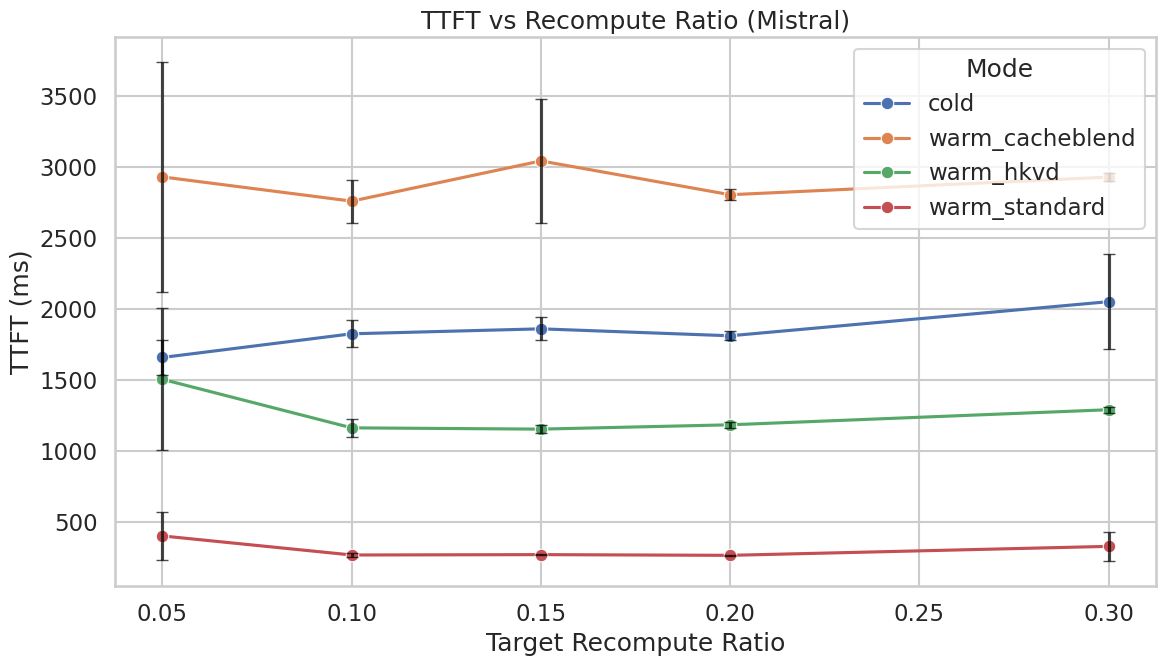

In [10]:
# 8) Visualization 1: TTFT by mode and ratio
sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(12, 7))
ax = sns.lineplot(
    data=summary,
    x="ratio",
    y="ttft_mean_ms",
    hue="mode",
    marker="o",
)

# Add error bars manually from std
for _, row in summary.iterrows():
    if pd.notna(row["ttft_std_ms"]):
        ax.errorbar(
            row["ratio"],
            row["ttft_mean_ms"],
            yerr=row["ttft_std_ms"],
            fmt="none",
            capsize=4,
            alpha=0.7,
            color="black",
        )

plt.title("TTFT vs Recompute Ratio (Mistral)")
plt.xlabel("Target Recompute Ratio")
plt.ylabel("TTFT (ms)")
plt.legend(title="Mode")
plt.tight_layout()
plt.show()

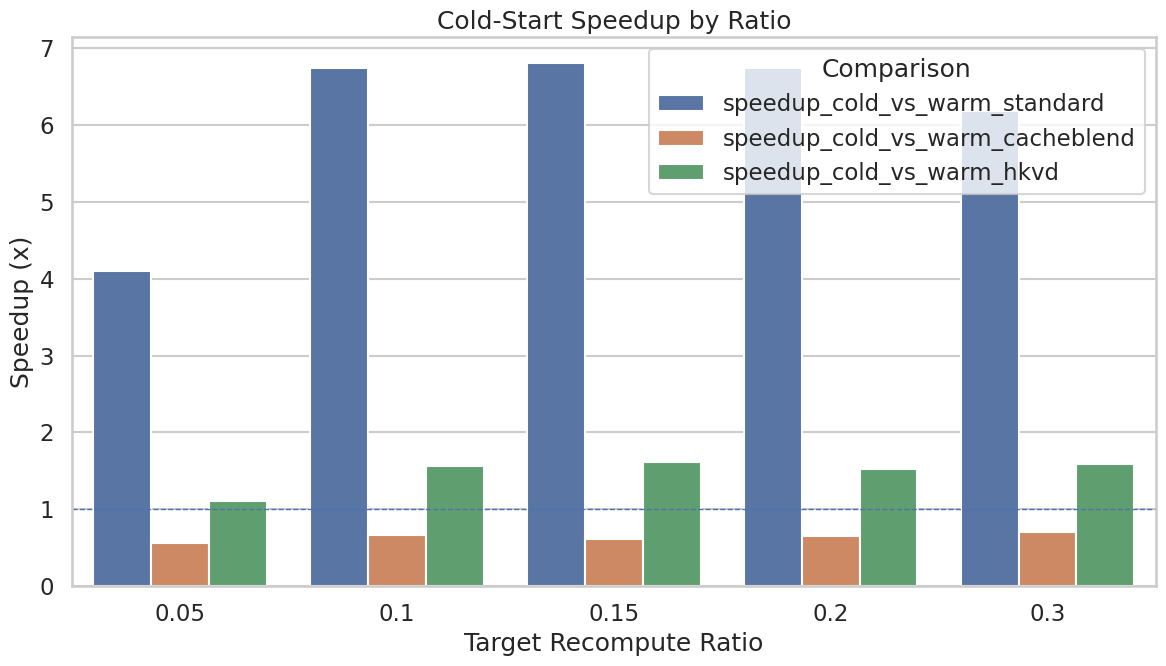

In [11]:
# 9) Visualization 2: Speedup bars by ratio
speed_cols = [
    c
    for c in [
        "speedup_cold_vs_warm_standard",
        "speedup_cold_vs_warm_cacheblend",
        "speedup_cold_vs_warm_hkvd",
    ]
    if c in wide.columns
]
plot_df = wide[["ratio"] + speed_cols].melt(id_vars="ratio", var_name="comparison", value_name="speedup")

plt.figure(figsize=(12, 7))
sns.barplot(data=plot_df, x="ratio", y="speedup", hue="comparison")
plt.axhline(1.0, linestyle="--", linewidth=1)
plt.title("Cold-Start Speedup by Ratio")
plt.xlabel("Target Recompute Ratio")
plt.ylabel("Speedup (x)")
plt.legend(title="Comparison")
plt.tight_layout()
plt.show()

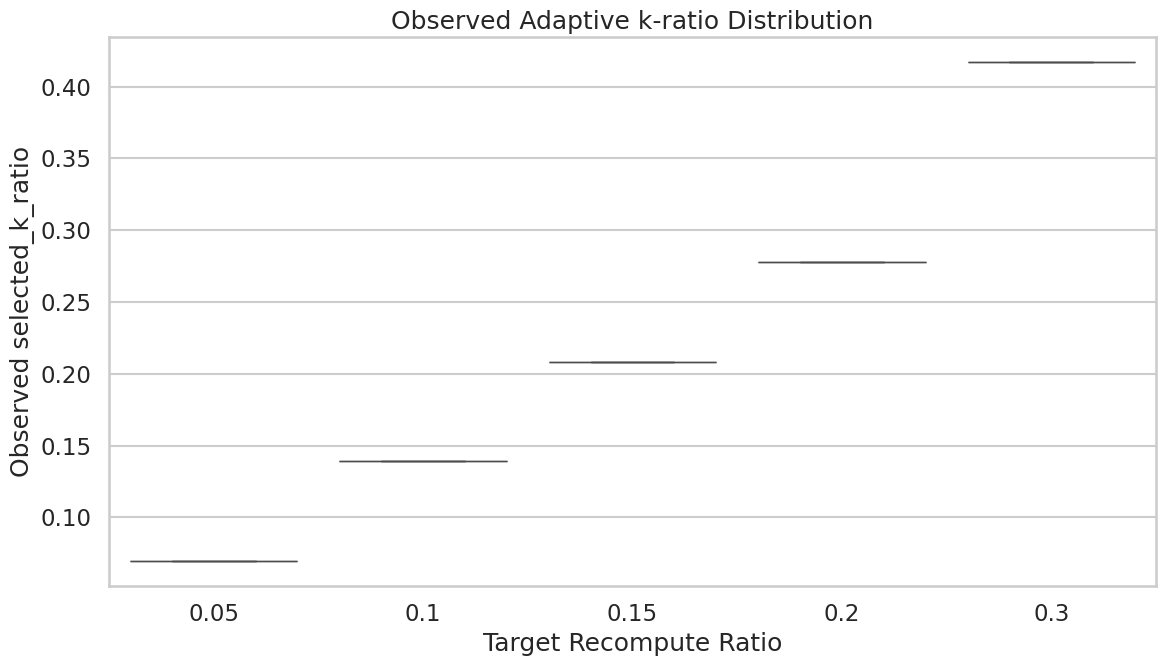

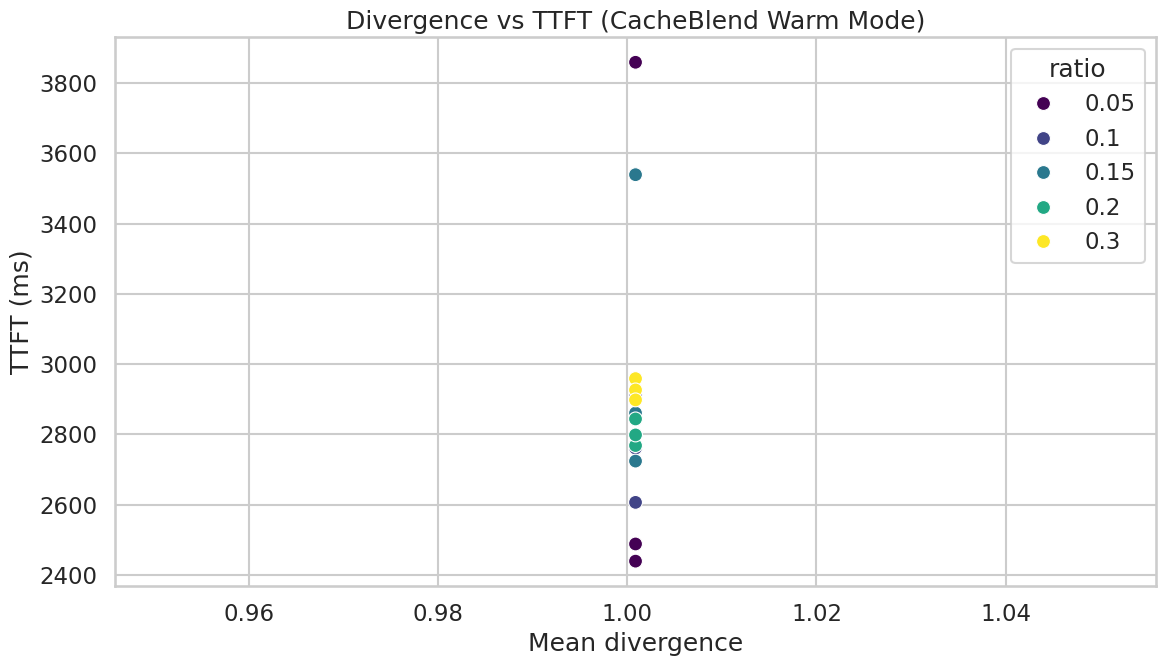

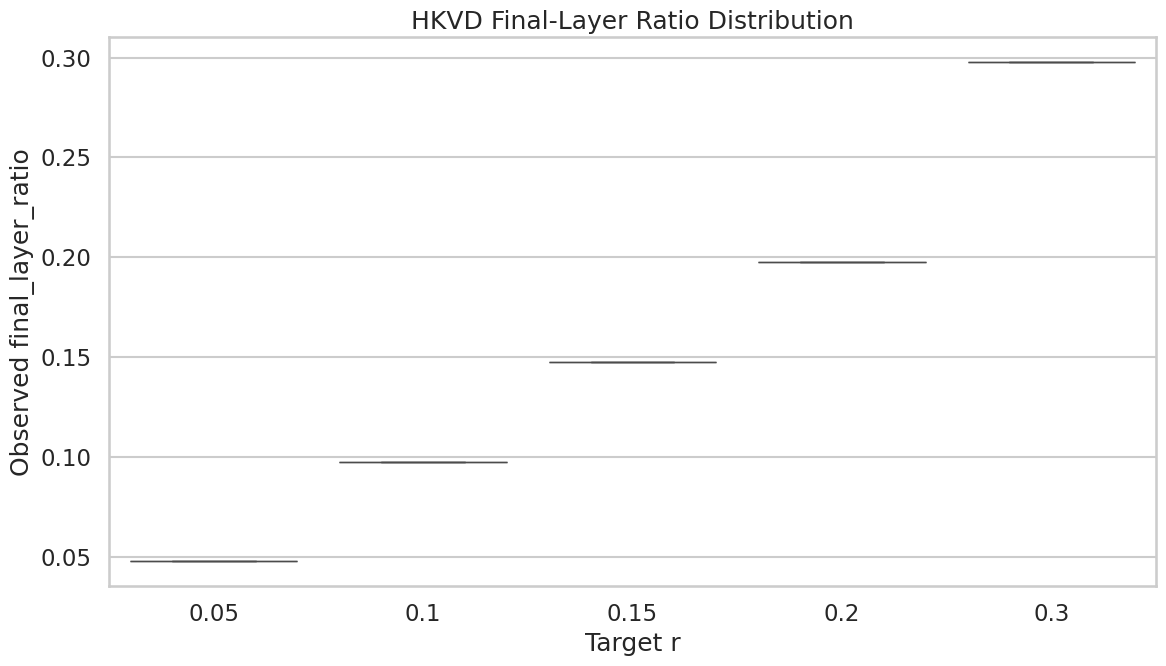

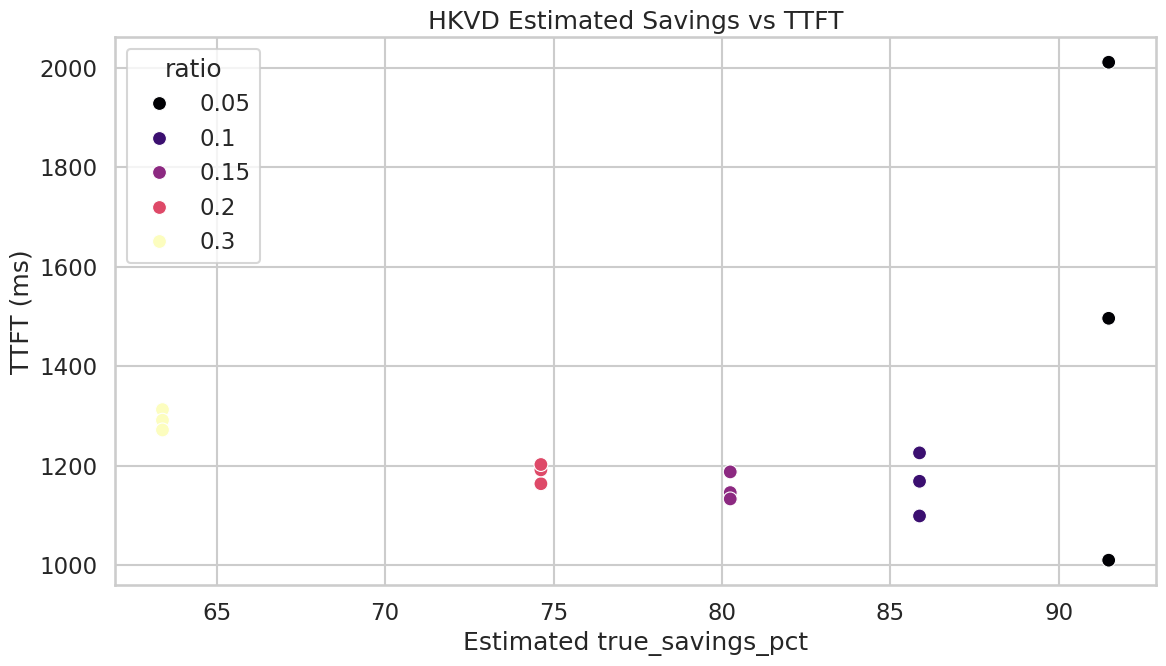

In [12]:
# 10) Visualization 3: Adaptive selector behavior
cb_df = df[df["mode"] == "warm_cacheblend"].copy()
if "selected_k_ratio" in cb_df.columns and cb_df["selected_k_ratio"].notna().any():
    plt.figure(figsize=(12, 7))
    sns.boxplot(data=cb_df, x="ratio", y="selected_k_ratio")
    plt.title("Observed Adaptive k-ratio Distribution")
    plt.xlabel("Target Recompute Ratio")
    plt.ylabel("Observed selected_k_ratio")
    plt.tight_layout()
    plt.show()

if "mean_divergence" in cb_df.columns and cb_df["mean_divergence"].notna().any():
    plt.figure(figsize=(12, 7))
    sns.scatterplot(data=cb_df, x="mean_divergence", y="ttft_ms", hue="ratio", palette="viridis", s=100)
    plt.title("Divergence vs TTFT (CacheBlend Warm Mode)")
    plt.xlabel("Mean divergence")
    plt.ylabel("TTFT (ms)")
    plt.tight_layout()
    plt.show()

hkvd_df = df[df["mode"] == "warm_hkvd"].copy()
if "hkvd_final_ratio_mean" in hkvd_df.columns and hkvd_df["hkvd_final_ratio_mean"].notna().any():
    plt.figure(figsize=(12, 7))
    sns.boxplot(data=hkvd_df, x="ratio", y="hkvd_final_ratio_mean")
    plt.title("HKVD Final-Layer Ratio Distribution")
    plt.xlabel("Target r")
    plt.ylabel("Observed final_layer_ratio")
    plt.tight_layout()
    plt.show()

if "hkvd_savings_pct_mean" in hkvd_df.columns and hkvd_df["hkvd_savings_pct_mean"].notna().any():
    plt.figure(figsize=(12, 7))
    sns.scatterplot(data=hkvd_df, x="hkvd_savings_pct_mean", y="ttft_ms", hue="ratio", palette="magma", s=100)
    plt.title("HKVD Estimated Savings vs TTFT")
    plt.xlabel("Estimated true_savings_pct")
    plt.ylabel("TTFT (ms)")
    plt.tight_layout()
    plt.show()

## Notes for Presentation and Report

- Use the `summary` table and the three plots as your primary visuals.
- Recommended claims format:
  - "Warm standard cache achieved X.x speedup over cold prefill."
  - "CacheBlend warm achieved Y.y speedup at ratio r=..."
  - "Observed adaptive ratio trends indicate ..."
- If `warm_cacheblend` is slower than `warm_standard`, frame it honestly as:
  - correctness and reproducibility achieved,
  - optimization opportunity in recompute/blend overhead,
  - next work: CUDA kernel tuning and selector threshold calibration.

## Common Issues

1. **OOM on Mistral 7B**
   - Reduce chunk size/repetitions.
   - Lower trials.
   - Switch model to `TinyLlama/TinyLlama-1.1B-Chat-v1.0` for quick dry runs.

2. **Private model/repo auth failures**
   - Ensure `HF_TOKEN` and `GITHUB_TOKEN` are set in Colab Secrets.

3. **Slow runtime**
   - Lower `TRIALS` first.
   - Use smaller workload for iteration, then re-run full workload once.

## 11) Stale-Context Quality vs Latency Track

This section demonstrates the report narrative:
- `warm_standard` is usually fastest,
- but can lose quality when cache is stale/mismatched,
- while `warm_cacheblend` may recover quality by selective recomputation.

Method:
1. Build a cache from `cached_chunks`.
2. Reuse that cache for `query_chunks` (edited/updated context) by mapping stale KV to query keys.
3. Compare modes against a cold reference output from the updated context.

Quality metric: **ROUGE-L** vs cold reference output (proxy for faithfulness to updated context).

In [13]:
# 12) Stale-context experiment setup
import evaluate

QUALITY_RATIO = 0.15
QUALITY_TRIALS = 2
QUALITY_MAX_NEW_TOKENS = 64
QUALITY_MIN_NEW_TOKENS = 24

rouge = evaluate.load("rouge")

stale_cases = [
    {
        "case_id": "capital_update",
        "prompt": "What is the capital of Kazakhstan today?",
        "cached_chunks": [
            "Kazakhstan's capital is Astana. It was briefly renamed to Nur-Sultan in 2019.",
            "In 2022, the city name reverted from Nur-Sultan back to Astana.",
        ],
        "query_chunks": [
            "Kazakhstan's capital is Astana. The 2019 rename to Nur-Sultan was later reversed.",
            "As of recent updates, the official capital name is Astana.",
        ],
    },
    {
        "case_id": "policy_revision",
        "prompt": "Summarize the latest policy status.",
        "cached_chunks": [
            "The policy draft stated mandatory quarterly reporting for all teams.",
            "Enforcement was planned to begin in Q1 with strict penalties.",
        ],
        "query_chunks": [
            "The revised policy now requires semi-annual reporting for most teams.",
            "Enforcement start was postponed, and penalties were softened in the update.",
        ],
    },
    {
        "case_id": "product_specs_change",
        "prompt": "What are the current product specs and launch timing?",
        "cached_chunks": [
            "The product launch was planned for June with 8GB memory and a 60Wh battery.",
            "Initial batch targeted enterprise customers only.",
        ],
        "query_chunks": [
            "The updated plan moves launch to September with 16GB memory and a 72Wh battery.",
            "Rollout now includes enterprise and education segments.",
        ],
    },
]

print("Stale cases:", [c["case_id"] for c in stale_cases])

Stale cases: ['capital_update', 'policy_revision', 'product_specs_change']


Quality summary:


,mode,ttft_mean_ms,ttft_std_ms,rougeL_mean,rougeL_std,n
0,cold_reference,6761.079080,860.316914,1.000000,0.000000,6
1,warm_cacheblend_stale,7109.689895,1189.239274,0.041667,0.064550,6
2,warm_standard_stale,5927.229431,357.117050,0.094493,0.114374,6


Sample qualitative outputs (trial 1 per case):


,case_id,prompt,cold_reference,warm_standard_stale,warm_cacheblend_stale
0,capital_update,What is the capital of Kazakhstan today?,Sultan was reversed.,Sultan honor of 19 in honor of the city is the...,own\n\n\n\n\n\n\n\n\n\n\n\n\n\n -----\n\n--...
1,policy_revision,Summarize the latest policy status.,ual inspeers of the first- The new teams that ...,,",,- to to that to to to to, the the the to ( (..."
2,product_specs_change,What are the current product specs and launch ...,inches and 12.90 capacity.\n\n\n\n\n\n\n\n\n\n...,"and 12.500. However,Samsungarrivalong the pric...",ciocioante stillciocioantemante\n Wciocio--- (...


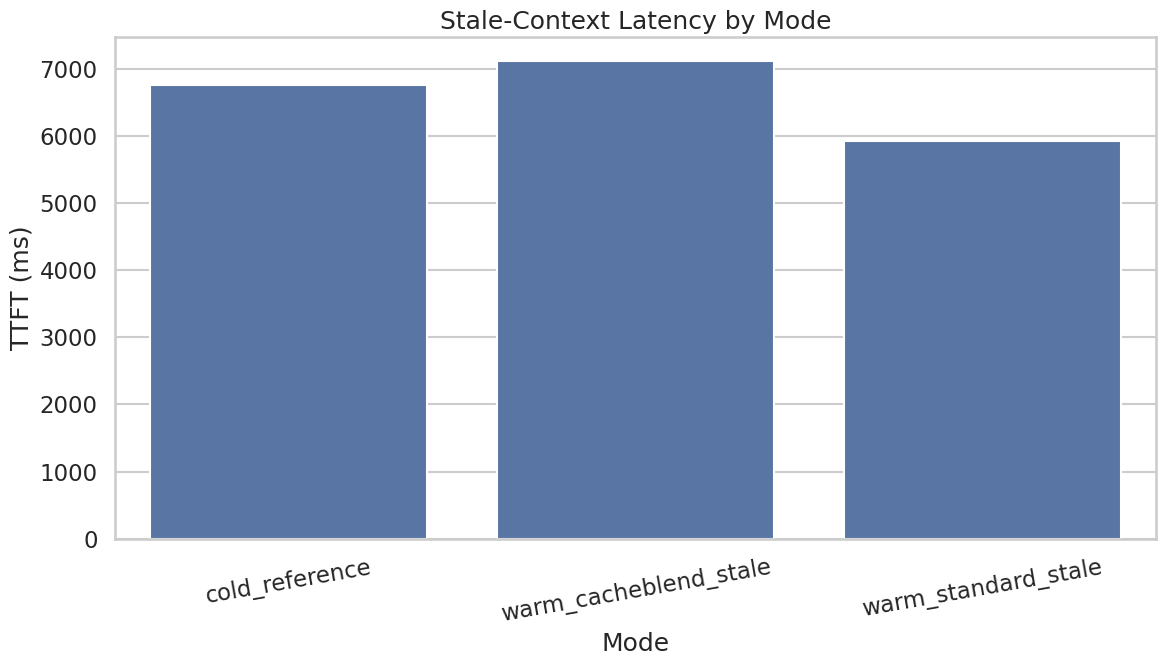

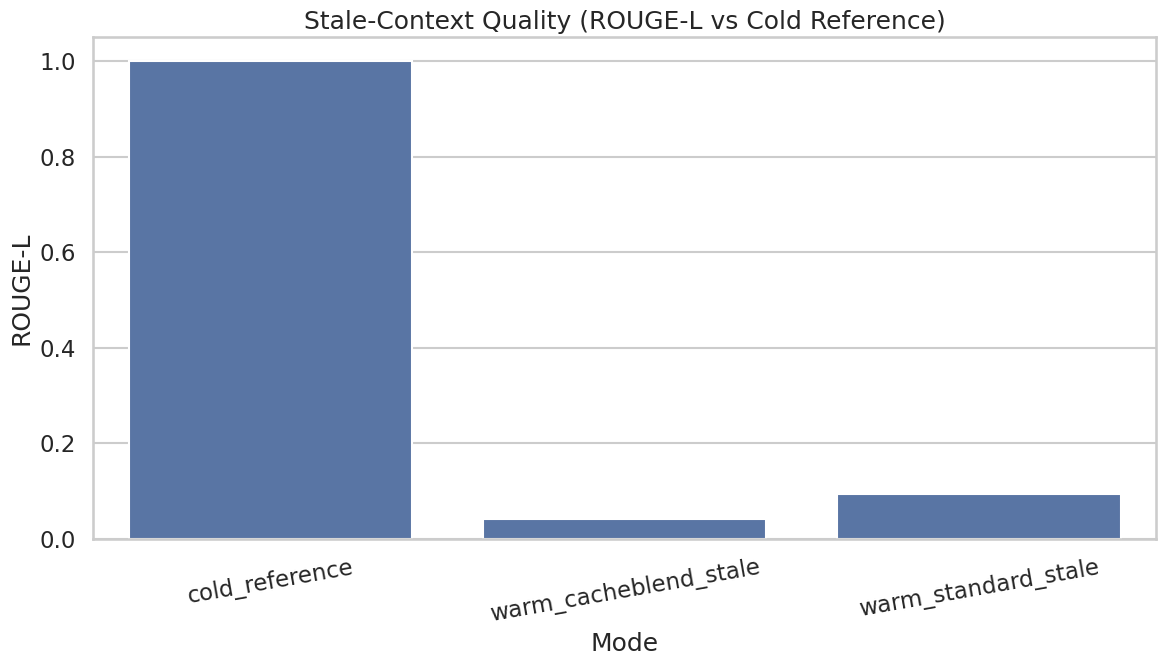

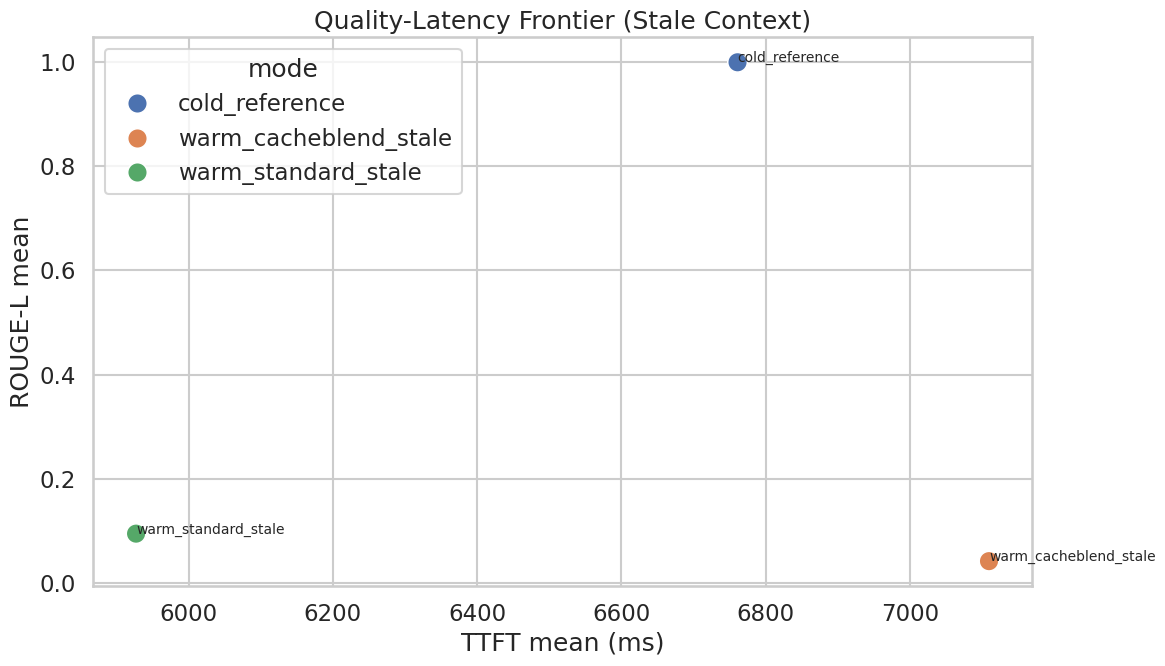

Saved stale-quality JSON -> /content/results/cacheblend_stale_quality_results.json
Saved stale-quality CSV  -> /content/results/cacheblend_stale_quality_results.csv


In [14]:
# 13) Run stale-context quality/latency benchmark + visualizations

def build_stale_mapped_store(cached_chunks, query_chunks):
    """
    Build KV from cached_chunks, but store under query_chunks keys to simulate stale cache reuse.

    Important: selector/recompute path expects cached KV token length to match query token length.
    We align stale KV length to query length by truncating or zero-padding along token dimension.
    """
    store = KVCacheStore()
    assert len(cached_chunks) == len(query_chunks)

    for cached_text, query_text in zip(cached_chunks, query_chunks):
        # Length target comes from the query side (what pipeline will run on).
        q_enc = tokenizer(
            query_text,
            return_tensors="pt",
            return_attention_mask=True,
            truncation=True,
            max_length=MAX_CHUNK_LEN,
        )
        q_len = int(q_enc["input_ids"].shape[1])

        c_enc = tokenizer(
            cached_text,
            return_tensors="pt",
            return_attention_mask=True,
            truncation=True,
            max_length=MAX_CHUNK_LEN,
        )
        c_ids = c_enc["input_ids"].to("cuda")
        c_attn = c_enc["attention_mask"].to("cuda")

        with torch.no_grad():
            out = model(c_ids, attention_mask=c_attn, use_cache=True)
        kv = pack_kv(out.past_key_values)  # (L, 2, N_cached, H, D)

        n_cached = int(kv.shape[2])
        if n_cached > q_len:
            kv = kv[:, :, :q_len, :, :]
        elif n_cached < q_len:
            pad = torch.zeros(
                kv.shape[0], kv.shape[1], q_len - n_cached, kv.shape[3], kv.shape[4],
                dtype=kv.dtype,
                device=kv.device,
            )
            kv = torch.cat([kv, pad], dim=2)

        # Store under query text key to force a warm hit with stale KV.
        store.store(query_text, kv)

    return store


def make_runtime_components(k_ratio):
    selector = AdaptiveTokenSelector(
        model=model,
        min_k_ratio=max(0.01, k_ratio * 0.5),
        max_k_ratio=min(0.50, k_ratio * 1.5),
        low_thresh=0.20,
        high_thresh=1.10,
    )
    recomputer = SelectiveRecomputer(model)
    blender = KVBlender()
    return selector, recomputer, blender


quality_records = []
example_outputs = []

for case in stale_cases:
    for trial in range(1, QUALITY_TRIALS + 1):
        case_id = case["case_id"]
        prompt_q = case["prompt"]
        query_chunks = case["query_chunks"]
        cached_chunks = case["cached_chunks"]

        # Cold reference on updated context
        cold_store = KVCacheStore()
        sel_c, rec_c, bl_c = make_runtime_components(QUALITY_RATIO)
        cold_out = cacheblend_generate(
            prompt_q,
            query_chunks,
            model,
            tokenizer,
            cold_store,
            sel_c,
            rec_c,
            bl_c,
            mode="standard_cache",
            benchmark_first_token=False,
            do_sample=False,
            max_new_tokens=QUALITY_MAX_NEW_TOKENS,
            min_new_tokens=QUALITY_MIN_NEW_TOKENS,
        )

        # Warm standard on stale cache
        stale_store_std = build_stale_mapped_store(cached_chunks, query_chunks)
        sel_s, rec_s, bl_s = make_runtime_components(QUALITY_RATIO)
        warm_std_out = cacheblend_generate(
            prompt_q,
            query_chunks,
            model,
            tokenizer,
            stale_store_std,
            sel_s,
            rec_s,
            bl_s,
            mode="standard_cache",
            benchmark_first_token=False,
            do_sample=False,
            max_new_tokens=QUALITY_MAX_NEW_TOKENS,
            min_new_tokens=QUALITY_MIN_NEW_TOKENS,
        )

        # Warm CacheBlend on stale cache
        stale_store_cb = build_stale_mapped_store(cached_chunks, query_chunks)
        sel_cb, rec_cb, bl_cb = make_runtime_components(QUALITY_RATIO)
        warm_cb_out = cacheblend_generate(
            prompt_q,
            query_chunks,
            model,
            tokenizer,
            stale_store_cb,
            sel_cb,
            rec_cb,
            bl_cb,
            mode="cacheblend",
            benchmark_first_token=False,
            do_sample=False,
            max_new_tokens=QUALITY_MAX_NEW_TOKENS,
            min_new_tokens=QUALITY_MIN_NEW_TOKENS,
        )

        ref_text = cold_out["text"]
        std_text = warm_std_out["text"]
        cb_text = warm_cb_out["text"]

        std_rouge = rouge.compute(predictions=[std_text], references=[ref_text])["rougeL"]
        cb_rouge = rouge.compute(predictions=[cb_text], references=[ref_text])["rougeL"]

        quality_records.extend([
            {
                "case_id": case_id,
                "trial": trial,
                "mode": "cold_reference",
                "ttft_ms": cold_out["ttft_ms"],
                "rougeL_vs_cold": 1.0,
            },
            {
                "case_id": case_id,
                "trial": trial,
                "mode": "warm_standard_stale",
                "ttft_ms": warm_std_out["ttft_ms"],
                "rougeL_vs_cold": std_rouge,
            },
            {
                "case_id": case_id,
                "trial": trial,
                "mode": "warm_cacheblend_stale",
                "ttft_ms": warm_cb_out["ttft_ms"],
                "rougeL_vs_cold": cb_rouge,
                "selected_k_ratio": sel_cb.get_last_selection_stats().get("selected_k_ratio", None),
                "mean_divergence": sel_cb.get_last_selection_stats().get("mean_divergence", None),
            },
        ])

        if trial == 1:
            example_outputs.append(
                {
                    "case_id": case_id,
                    "prompt": prompt_q,
                    "cold_reference": ref_text,
                    "warm_standard_stale": std_text,
                    "warm_cacheblend_stale": cb_text,
                }
            )

quality_df = pd.DataFrame(quality_records)
quality_summary = (
    quality_df.groupby("mode", as_index=False)
    .agg(
        ttft_mean_ms=("ttft_ms", "mean"),
        ttft_std_ms=("ttft_ms", "std"),
        rougeL_mean=("rougeL_vs_cold", "mean"),
        rougeL_std=("rougeL_vs_cold", "std"),
        n=("mode", "count"),
    )
)

print("Quality summary:")
display(quality_summary)

print("Sample qualitative outputs (trial 1 per case):")
display(pd.DataFrame(example_outputs))

# Plot A: Latency comparison in stale context
plt.figure(figsize=(12, 7))
sns.barplot(data=quality_summary, x="mode", y="ttft_mean_ms")
plt.title("Stale-Context Latency by Mode")
plt.xlabel("Mode")
plt.ylabel("TTFT (ms)")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

# Plot B: Quality comparison in stale context
plt.figure(figsize=(12, 7))
sns.barplot(data=quality_summary, x="mode", y="rougeL_mean")
plt.title("Stale-Context Quality (ROUGE-L vs Cold Reference)")
plt.xlabel("Mode")
plt.ylabel("ROUGE-L")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

# Plot C: Quality-latency frontier
plt.figure(figsize=(12, 7))
sns.scatterplot(data=quality_summary, x="ttft_mean_ms", y="rougeL_mean", hue="mode", s=200)
for _, row in quality_summary.iterrows():
    plt.text(row["ttft_mean_ms"], row["rougeL_mean"], row["mode"], fontsize=10)
plt.title("Quality-Latency Frontier (Stale Context)")
plt.xlabel("TTFT mean (ms)")
plt.ylabel("ROUGE-L mean")
plt.tight_layout()
plt.show()

# Save stale-track outputs
quality_json_path = f"{RESULTS_DIR}/cacheblend_stale_quality_results.json"
quality_csv_path = f"{RESULTS_DIR}/cacheblend_stale_quality_results.csv"

with open(quality_json_path, "w") as f:
    json.dump(
        {
            "config": {
                "quality_ratio": QUALITY_RATIO,
                "quality_trials": QUALITY_TRIALS,
                "max_new_tokens": QUALITY_MAX_NEW_TOKENS,
                "min_new_tokens": QUALITY_MIN_NEW_TOKENS,
            },
            "summary": quality_summary.to_dict(orient="records"),
            "raw": quality_df.to_dict(orient="records"),
            "examples": example_outputs,
        },
        f,
        indent=2,
    )

quality_df.to_csv(quality_csv_path, index=False)
print(f"Saved stale-quality JSON -> {quality_json_path}")
print(f"Saved stale-quality CSV  -> {quality_csv_path}")

## 13b) Enhanced Stale-Context Benchmark (adds HKVD + factual scoring)

Run this cell instead of the older stale benchmark cell when you want:
- `warm_hkvd_stale` included
- ROUGE-L vs cold reference
- simple factual keyword match score (case-specific)

This gives a stronger report table for quality/latency tradeoffs.

In [ ]:
# 13c) Run enhanced stale benchmark (standard vs cacheblend vs HKVD)
import re

# Case-specific factual keywords for a lightweight factuality score.
# Score = fraction of keywords present in generated output.
FACT_KEYWORDS = {
    "capital_update": ["astana", "capital"],
    "policy_revision": ["semi-annual", "quarterly", "postponed", "softened"],
    "product_specs_change": ["september", "16gb", "72wh", "education"],
}


def normalize_text(s: str) -> str:
    s = (s or "").lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s


def factual_keyword_score(text: str, keywords):
    t = normalize_text(text)
    if not keywords:
        return 0.0
    hits = sum(1 for k in keywords if k.lower() in t)
    return hits / len(keywords)


def make_hkvd_fusor(k_ratio: float):
    # CacheBlendFusor imported earlier in benchmark utilities cell.
    return CacheBlendFusor(model, r=float(k_ratio))


enhanced_records = []
enhanced_examples = []

for case in stale_cases:
    case_id = case["case_id"]
    prompt_q = case["prompt"]
    query_chunks = case["query_chunks"]
    cached_chunks = case["cached_chunks"]
    keywords = FACT_KEYWORDS.get(case_id, [])

    for trial in range(1, QUALITY_TRIALS + 1):
        # 1) Cold reference on updated context
        cold_store = KVCacheStore()
        sel_c, rec_c, bl_c = make_runtime_components(QUALITY_RATIO)
        cold_out = cacheblend_generate(
            prompt_q,
            query_chunks,
            model,
            tokenizer,
            cold_store,
            sel_c,
            rec_c,
            bl_c,
            mode="standard_cache",
            benchmark_first_token=False,
            do_sample=False,
            max_new_tokens=QUALITY_MAX_NEW_TOKENS,
            min_new_tokens=QUALITY_MIN_NEW_TOKENS,
        )

        # 2) Warm standard with stale cache
        stale_store_std = build_stale_mapped_store(cached_chunks, query_chunks)
        sel_s, rec_s, bl_s = make_runtime_components(QUALITY_RATIO)
        warm_std_out = cacheblend_generate(
            prompt_q,
            query_chunks,
            model,
            tokenizer,
            stale_store_std,
            sel_s,
            rec_s,
            bl_s,
            mode="standard_cache",
            benchmark_first_token=False,
            do_sample=False,
            max_new_tokens=QUALITY_MAX_NEW_TOKENS,
            min_new_tokens=QUALITY_MIN_NEW_TOKENS,
        )

        # 3) Warm modular CacheBlend with stale cache
        stale_store_cb = build_stale_mapped_store(cached_chunks, query_chunks)
        sel_cb, rec_cb, bl_cb = make_runtime_components(QUALITY_RATIO)
        warm_cb_out = cacheblend_generate(
            prompt_q,
            query_chunks,
            model,
            tokenizer,
            stale_store_cb,
            sel_cb,
            rec_cb,
            bl_cb,
            mode="cacheblend",
            benchmark_first_token=False,
            do_sample=False,
            max_new_tokens=QUALITY_MAX_NEW_TOKENS,
            min_new_tokens=QUALITY_MIN_NEW_TOKENS,
        )

        # 4) Warm HKVD fusor with stale cache
        stale_store_hkvd = build_stale_mapped_store(cached_chunks, query_chunks)
        fusor = make_hkvd_fusor(QUALITY_RATIO)
        hkvd_error = None
        try:
            warm_hkvd_out = cacheblend_generate_hkvd(
                prompt_q,
                query_chunks,
                model,
                tokenizer,
                stale_store_hkvd,
                fusor,
                benchmark_first_token=False,
                do_sample=False,
                max_new_tokens=QUALITY_MAX_NEW_TOKENS,
                min_new_tokens=QUALITY_MIN_NEW_TOKENS,
            )
        except Exception as e:
            hkvd_error = str(e)
            warm_hkvd_out = {
                "text": "",
                "ttft_ms": float("nan"),
                "cache_hits": None,
                "cache_misses": None,
                "hkvd_final_ratio_mean": None,
                "hkvd_savings_pct_mean": None,
            }

        # Metrics against cold reference text
        ref_text = cold_out["text"]
        std_text = warm_std_out["text"]
        cb_text = warm_cb_out["text"]
        hkvd_text = warm_hkvd_out["text"]

        std_rouge = rouge.compute(predictions=[std_text], references=[ref_text])["rougeL"]
        cb_rouge = rouge.compute(predictions=[cb_text], references=[ref_text])["rougeL"]
        hkvd_rouge = rouge.compute(predictions=[hkvd_text], references=[ref_text])["rougeL"] if hkvd_error is None else float("nan")

        cold_fact = factual_keyword_score(ref_text, keywords)
        std_fact = factual_keyword_score(std_text, keywords)
        cb_fact = factual_keyword_score(cb_text, keywords)
        hkvd_fact = factual_keyword_score(hkvd_text, keywords) if hkvd_error is None else float("nan")

        enhanced_records.extend([
            {
                "case_id": case_id,
                "trial": trial,
                "mode": "cold_reference",
                "ttft_ms": cold_out["ttft_ms"],
                "rougeL_vs_cold": 1.0,
                "fact_score": cold_fact,
            },
            {
                "case_id": case_id,
                "trial": trial,
                "mode": "warm_standard_stale",
                "ttft_ms": warm_std_out["ttft_ms"],
                "rougeL_vs_cold": std_rouge,
                "fact_score": std_fact,
            },
            {
                "case_id": case_id,
                "trial": trial,
                "mode": "warm_cacheblend_stale",
                "ttft_ms": warm_cb_out["ttft_ms"],
                "rougeL_vs_cold": cb_rouge,
                "fact_score": cb_fact,
                "selected_k_ratio": sel_cb.get_last_selection_stats().get("selected_k_ratio", None),
                "mean_divergence": sel_cb.get_last_selection_stats().get("mean_divergence", None),
            },
            {
                "case_id": case_id,
                "trial": trial,
                "mode": "warm_hkvd_stale",
                "ttft_ms": warm_hkvd_out["ttft_ms"],
                "rougeL_vs_cold": hkvd_rouge,
                "fact_score": hkvd_fact,
                "hkvd_final_ratio_mean": warm_hkvd_out.get("hkvd_final_ratio_mean", None),
                "hkvd_savings_pct_mean": warm_hkvd_out.get("hkvd_savings_pct_mean", None),
                "hkvd_error": hkvd_error,
            },
        ])

        if trial == 1:
            enhanced_examples.append(
                {
                    "case_id": case_id,
                    "prompt": prompt_q,
                    "cold_reference": ref_text,
                    "warm_standard_stale": std_text,
                    "warm_cacheblend_stale": cb_text,
                    "warm_hkvd_stale": hkvd_text,
                    "hkvd_error": hkvd_error,
                }
            )

enhanced_df = pd.DataFrame(enhanced_records)
enhanced_summary = (
    enhanced_df.groupby("mode", as_index=False)
    .agg(
        ttft_mean_ms=("ttft_ms", "mean"),
        ttft_std_ms=("ttft_ms", "std"),
        rougeL_mean=("rougeL_vs_cold", "mean"),
        rougeL_std=("rougeL_vs_cold", "std"),
        fact_mean=("fact_score", "mean"),
        fact_std=("fact_score", "std"),
        n=("mode", "count"),
    )
)

print("Enhanced quality summary:")
display(enhanced_summary)

print("Enhanced sample outputs (trial 1 per case):")
display(pd.DataFrame(enhanced_examples))

# Plot 1: latency
plt.figure(figsize=(12, 7))
sns.barplot(data=enhanced_summary, x="mode", y="ttft_mean_ms")
plt.title("Stale-Context Latency by Mode (Enhanced)")
plt.xlabel("Mode")
plt.ylabel("TTFT (ms)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Plot 2: ROUGE-L
plt.figure(figsize=(12, 7))
sns.barplot(data=enhanced_summary, x="mode", y="rougeL_mean")
plt.title("Stale-Context ROUGE-L vs Cold Reference (Enhanced)")
plt.xlabel("Mode")
plt.ylabel("ROUGE-L")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Plot 3: Factual keyword score
plt.figure(figsize=(12, 7))
sns.barplot(data=enhanced_summary, x="mode", y="fact_mean")
plt.title("Stale-Context Factual Keyword Score (Enhanced)")
plt.xlabel("Mode")
plt.ylabel("Factual score (0-1)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Plot 4: quality-latency frontier with factual color
plt.figure(figsize=(12, 7))
sns.scatterplot(data=enhanced_summary, x="ttft_mean_ms", y="rougeL_mean", hue="fact_mean", style="mode", s=220)
for _, row in enhanced_summary.iterrows():
    plt.text(row["ttft_mean_ms"], row["rougeL_mean"], row["mode"], fontsize=10)
plt.title("Quality-Latency Frontier (Enhanced Stale Context)")
plt.xlabel("TTFT mean (ms)")
plt.ylabel("ROUGE-L mean")
plt.tight_layout()
plt.show()

# Save outputs
enhanced_json_path = f"{RESULTS_DIR}/cacheblend_stale_quality_enhanced.json"
enhanced_csv_path = f"{RESULTS_DIR}/cacheblend_stale_quality_enhanced.csv"

with open(enhanced_json_path, "w") as f:
    json.dump(
        {
            "config": {
                "quality_ratio": QUALITY_RATIO,
                "quality_trials": QUALITY_TRIALS,
                "max_new_tokens": QUALITY_MAX_NEW_TOKENS,
                "min_new_tokens": QUALITY_MIN_NEW_TOKENS,
                "fact_keywords": FACT_KEYWORDS,
            },
            "summary": enhanced_summary.to_dict(orient="records"),
            "raw": enhanced_df.to_dict(orient="records"),
            "examples": enhanced_examples,
        },
        f,
        indent=2,
    )

enhanced_df.to_csv(enhanced_csv_path, index=False)
print(f"Saved enhanced stale-quality JSON -> {enhanced_json_path}")
print(f"Saved enhanced stale-quality CSV  -> {enhanced_csv_path}")